# 🌲 Notebook 04: Module 2 — Regression and Trees
## Evaluation of Regression, Logistic Models, Gini Index & CART Decision Trees

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from src.utils import load_numpy, save_model
from src.regression_models import (
    train_linear_regression, train_logistic_regression, evaluate_regression_model
)
from src.tree_models import train_decision_tree_classifier, train_decision_tree_regressor
from src.evaluation_metrics import compute_all_metrics, plot_confusion_matrix

X_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_train.npy"))
X_test = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_test.npy"))

y_train_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_binary.npy"))
y_test_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_binary.npy"))

y_train_sev = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_severity.npy"))
y_test_sev = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_severity.npy"))

sub_idx = np.random.choice(len(X_train), 20000, replace=False)
X_sub = X_train[sub_idx]
y_sub_bin = y_train_bin[sub_idx]
y_sub_sev = y_train_sev[sub_idx]

📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_train.npy | Shape: (125973, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_test.npy | Shape: (22544, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_binary.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_binary.npy | Shape: (22544,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_severity.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_severity.npy | Shape: (22544,)


In [2]:
lin_reg = train_linear_regression(X_sub, y_sub_sev)
lin_metrics = evaluate_regression_model(lin_reg, X_test, y_test_sev)
save_model(lin_reg, os.path.join(PROJECT_ROOT, "models", "saved_models", "linear_regression.pkl"))

cart_reg = train_decision_tree_regressor(X_sub, y_sub_sev, max_depth=10)
cart_metrics = evaluate_regression_model(cart_reg, X_test, y_test_sev)
save_model(cart_reg, os.path.join(PROJECT_ROOT, "models", "saved_models", "decision_tree_cart_regression.pkl"))

reg_results = pd.DataFrame([lin_metrics, cart_metrics], index=["Linear Regression", "CART Regressor"])
print(reg_results)
reg_results.to_csv(os.path.join(PROJECT_ROOT, "results", "regression_results.csv"))

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\linear_regression.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\decision_tree_cart_regression.pkl
                            mse          rmse           mae            r2
Linear Regression  2.350694e+22  1.533197e+11  3.386717e+09 -2.120458e+23
CART Regressor     6.821853e-02  2.611868e-01  1.217672e-01  3.846308e-01


In [3]:
log_reg = train_logistic_regression(X_sub, y_sub_bin)
save_model(log_reg, os.path.join(PROJECT_ROOT, "models", "saved_models", "logistic_regression.pkl"))

dt_gini = train_decision_tree_classifier(X_sub, y_sub_bin, criterion="gini", max_depth=10)
save_model(dt_gini, os.path.join(PROJECT_ROOT, "models", "saved_models", "decision_tree_gini.pkl"))

dt_cart = train_decision_tree_classifier(X_sub, y_sub_bin, criterion="entropy", max_depth=10)
save_model(dt_cart, os.path.join(PROJECT_ROOT, "models", "saved_models", "decision_tree_cart_classifier.pkl"))

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\logistic_regression.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\decision_tree_gini.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\decision_tree_cart_classifier.pkl


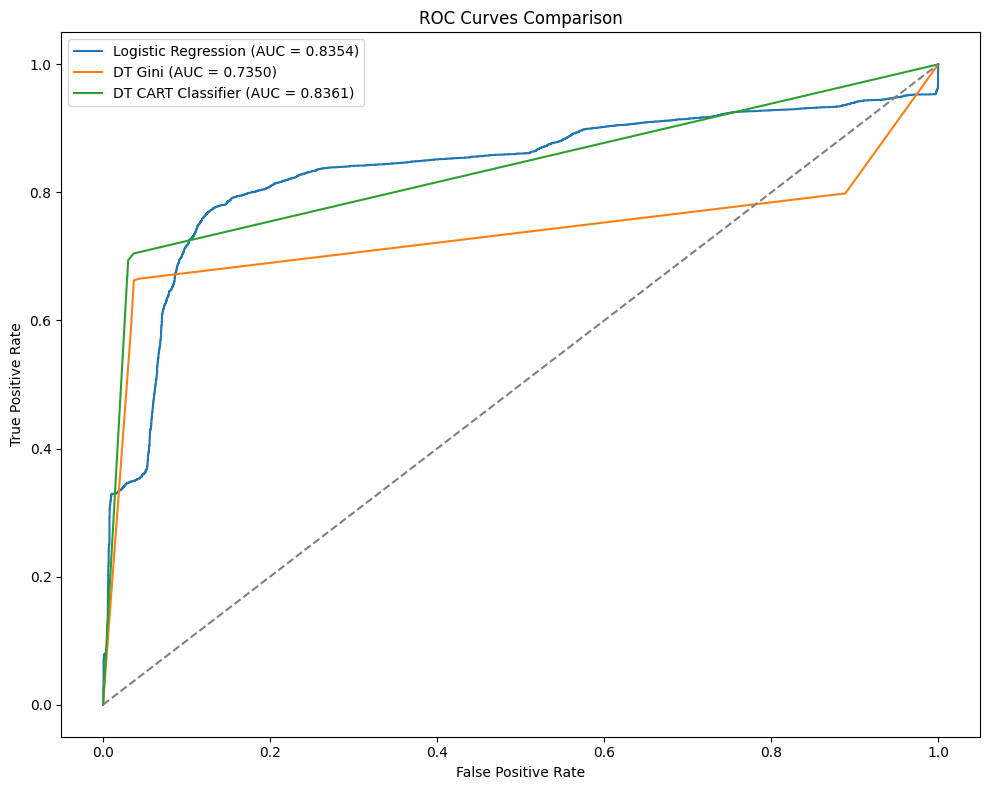

                 Model  Accuracy  Precision    Recall  F1-Score     Kappa  \
0  Logistic Regression  0.754968   0.917609  0.625731  0.744070  0.524659   
1              DT Gini  0.791474   0.959020  0.661965  0.783274  0.594961   
2   DT CART Classifier  0.797596   0.968290  0.666251  0.789364  0.606983   

   Sensitivity  Specificity       AUC  
0     0.625731     0.925754  0.835356  
1     0.661965     0.962620  0.735039  
2     0.666251     0.971167  0.836135  


In [4]:
models = {
    "Logistic Regression": (log_reg, log_reg.predict_proba(X_test)[:, 1]),
    "DT Gini": (dt_gini, dt_gini.predict_proba(X_test)[:, 1]),
    "DT CART Classifier": (dt_cart, dt_cart.predict_proba(X_test)[:, 1])
}

summary_data = []

fig, ax = plt.subplots(figsize=(10, 8))

for name, (model, probs) in models.items():
    preds = model.predict(X_test)
    metrics = compute_all_metrics(y_test_bin, preds, probs)
    
    summary_data.append({
        "Model": name,
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-Score": metrics["f1"],
        "Kappa": metrics["kappa"],
        "Sensitivity": metrics["sensitivity"],
        "Specificity": metrics["specificity"],
        "AUC": metrics["auc"]
    })
    
    plot_confusion_matrix(
        metrics["confusion_matrix"], 
        ["Normal", "Attack"], 
        f"CM: {name}",
        save_path=os.path.join(PROJECT_ROOT, "plots", "module2", f"confusion_matrix_{name.lower().replace(' ', '_')}.png")
    )
    
    fpr, tpr, _ = roc_curve(y_test_bin, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {metrics['auc']:.4f})")

ax.plot([0, 1], [0, 1], color="grey", linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves Comparison")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module2", "roc_curve_comparison.png"), dpi=150)
plt.show()

summary_df = pd.DataFrame(summary_data)
print(summary_df)
summary_df.to_csv(os.path.join(PROJECT_ROOT, "results", "module2_classification_results.csv"), index=False)